# Experimentos finales de las subsecciones 3.3 y 4.3

Las dos subsecciones reutilizan las mismas dos comparaciones deterministas entre Policy Iteration y Value Iteration.

In [1]:
# Imports y localización robusta de la raíz lab1.
from pathlib import Path
import sys
sys.dont_write_bytecode = True

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

cwd = Path.cwd().resolve()
candidates = (cwd, cwd / 'lab1', cwd.parent)
PROJECT_DIR = next(path for path in candidates if (path / 'env.py').is_file())
FINAL_EXPERIMENTS_DIR = PROJECT_DIR / 'final-experiments'
for path in (FINAL_EXPERIMENTS_DIR, PROJECT_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from experiment_utils import (
    BASE_GAMMA, BASE_TOL, GAMMAS, TOLERANCES, get_result,
    plot_time_comparison, plot_value_overlay, run_comparison,
    validate_results,
)

In [2]:
# Parámetros, seed y carpeta de salida.
RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)
FINAL_RESULTS_DIR = PROJECT_DIR / 'final-results'
FINAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'gamma base: {BASE_GAMMA}; theta base: {BASE_TOL}')
print(f'gammas: {GAMMAS}')
print(f'tolerancias: {TOLERANCES}')

gamma base: 0.9; theta base: 0.001
gammas: (0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0)
tolerancias: (10.0, 3.0, 1.0, 0.3, 0.1, 0.01, 0.001, 0.0001, 1e-06, 1e-08, 1e-10, 1e-12)


## Cálculo compartido por 3.3 y 4.3

Se comparan PI y VI sobre los cortes de $\gamma$ y $\theta$ utilizados por las dos figuras.

In [3]:
# Valores, políticas, barridos, evaluaciones elementales y tiempos.
comparison_rows = run_comparison()
base = get_result(comparison_rows, BASE_GAMMA, BASE_TOL)
print({
    'pi_outer': base['pi_outer'],
    'pi_eval_sweeps': base['pi_eval_sweeps'],
    'vi_sweeps': base['vi_sweeps'],
    'pi_evaluations': base['pi_evaluations'],
    'vi_evaluations': base['vi_evaluations'],
    'max_V_diff': base['max_V_diff'],
    'policies_equal': base['policies_equal'],
})

{'pi_outer': 3, 'pi_eval_sweeps': 11, 'vi_sweeps': 4, 'pi_evaluations': 357, 'vi_evaluations': 168, 'max_V_diff': 0.0, 'policies_equal': True}


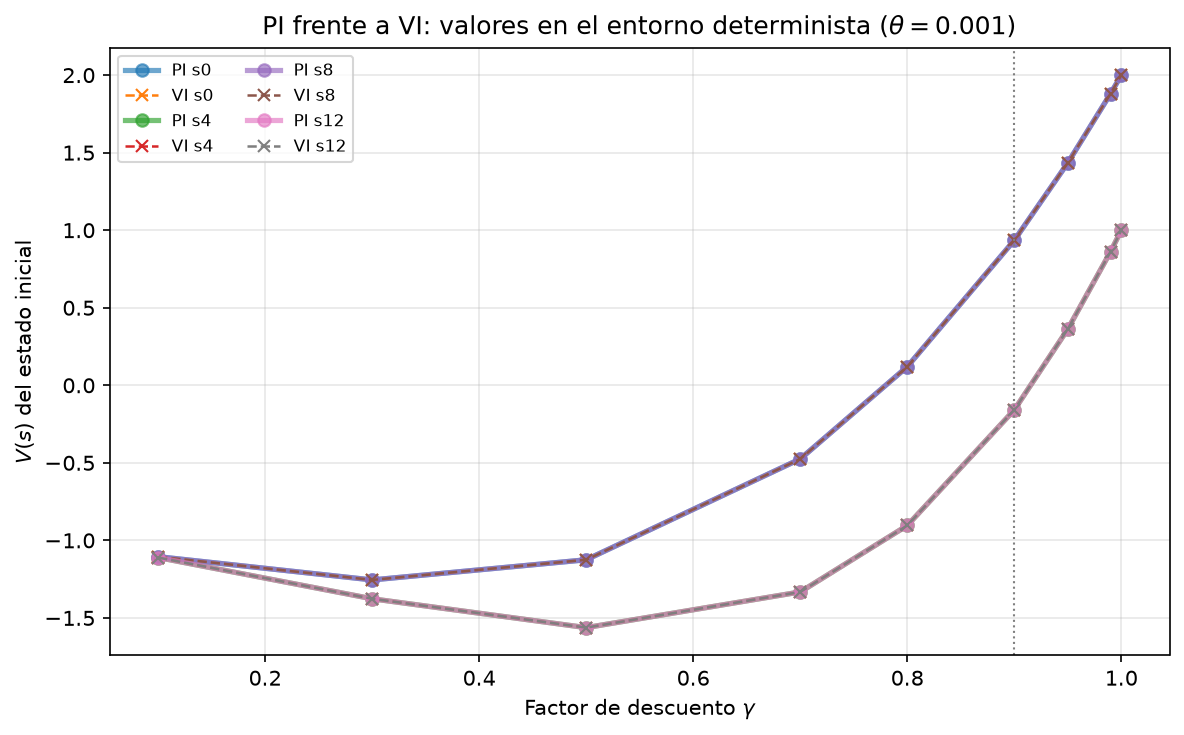

In [4]:
# Figura repetida en 3.3 y 4.3: valores de PI y VI frente a gamma.
figure = plot_value_overlay(comparison_rows, FINAL_RESULTS_DIR)
plt.close(figure)
display(Image(filename=str(FINAL_RESULTS_DIR / '1_value_overlay_deterministic.png')))

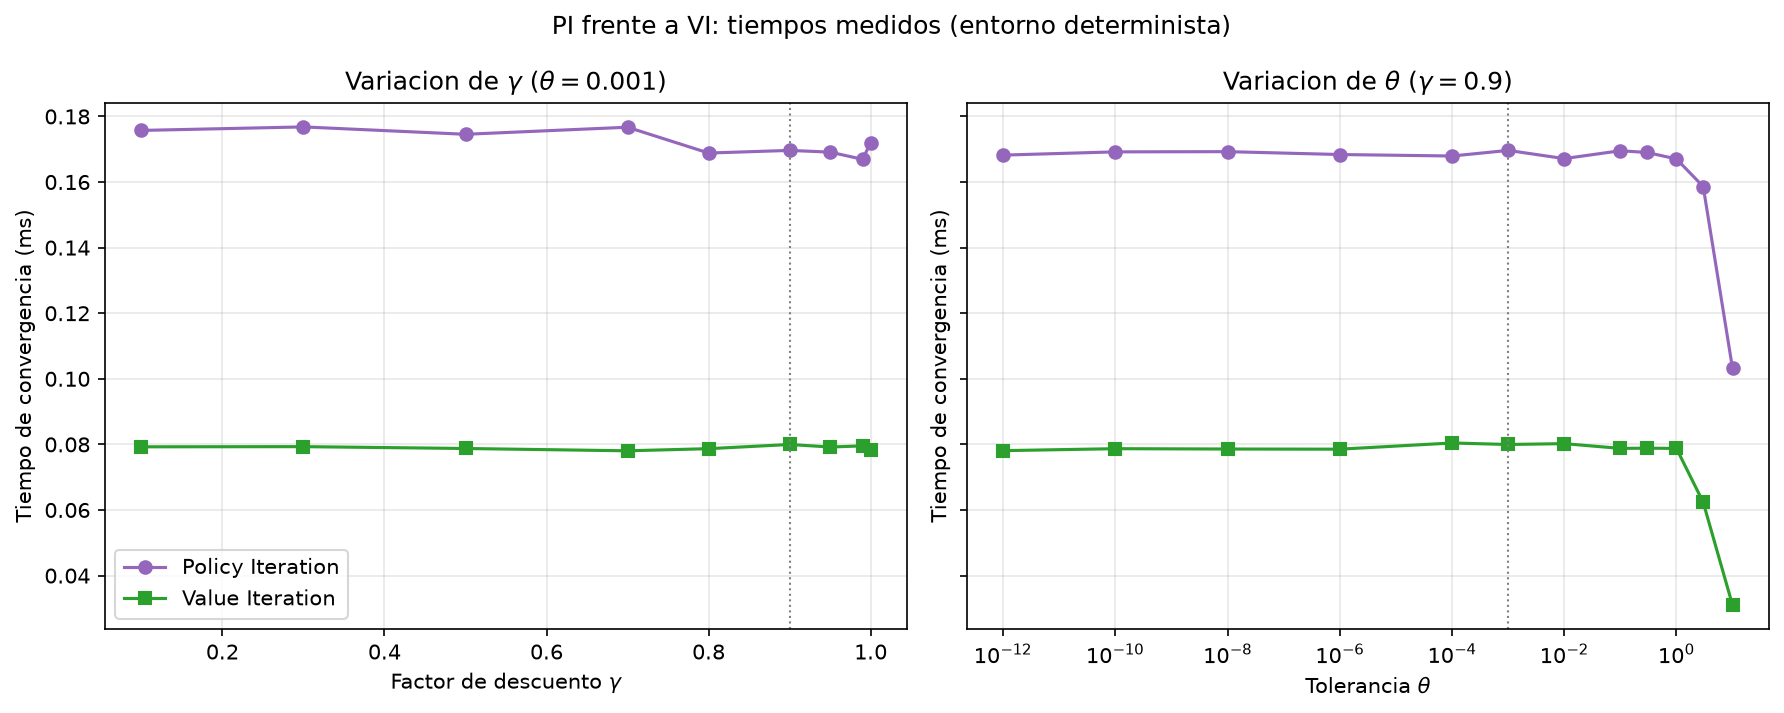

In [5]:
# Figura repetida en 3.3 y 4.3: tiempos frente a gamma y theta.
figure = plot_time_comparison(comparison_rows, FINAL_RESULTS_DIR)
plt.close(figure)
display(Image(filename=str(FINAL_RESULTS_DIR / '3_time_gamma_tol_deterministic.png')))

## Validación final

In [6]:
# Comprueba las cifras citadas y el conjunto exacto de dos imágenes.
EXPECTED_FIGURES = [
    '1_value_overlay_deterministic.png',
    '3_time_gamma_tol_deterministic.png',
]
validation = validate_results(
    comparison_rows, FINAL_RESULTS_DIR, EXPECTED_FIGURES
)
generated = sorted(path.name for path in FINAL_RESULTS_DIR.glob('*.png'))
assert generated == sorted(EXPECTED_FIGURES), (generated, EXPECTED_FIGURES)
print(f'Figuras generadas: {validation["figures"]}/{len(EXPECTED_FIGURES)}')
print(f'Tiempo base PI: {validation["pi_time_ms"]:.6f} ms')
print(f'Tiempo base VI: {validation["vi_time_ms"]:.6f} ms')
print(f'Ratio PI/VI: {validation["time_ratio_pi_over_vi"]:.3f}')
print('Validación numérica y nombres de figuras: OK')

Figuras generadas: 2/2
Tiempo base PI: 0.169640 ms
Tiempo base VI: 0.079976 ms
Ratio PI/VI: 2.121
Validación numérica y nombres de figuras: OK
